# Основи статистики

<table>
    <tr>
        <td>
            <h2></h2>Завдання 1
Потрібно проаналізувати дані транзакцій інтернет-магазину та візуалізувати розподіл сум замовлень. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
            <ul>
                <li>Завантажте дані з CSV у таблицю.</li>
                <li>Виведіть перші рядки та інформацію про стовпці.</li>
                <li>Визначте кількість пропусків за кожним стовпчиком.</li>
                <li>Побудуйте зведення за "amount": кількість, середнє, медіана, мінімум, максимум, квартилі та перцентилі.</li>
                <li>Побудуйте гістограму "amount" і коробчату діаграму.</li>
                <li>Видаліть пропуски в "amount" і повторіть розрахунок зведення.</li>
                <li>Виведіть усі результати та графіки.</li>
            </ul>
        </td>        
        <td>
            Медіана - величина, що ділить множину на 2 частини з однаковою кількістю елементів: для парної кількості медіана - це середнє між центральними елементами (після впорядкування), для непарної - значення центрального елемента<br/>
            Квартилі - величини, що поділяють множину на 4 частини з однаковою кількістю елементів (після впорядкування)<br/>
            Перцентилі (процентилі) - поділяють на 100 частин: 50-й перцентиль -- медіана, 25-й -- перший квартиль, 95-й -- перевірка простих гіпотез, 99-й -- перевірка надійних гіпотез, 100-й -- максимум.
        </td>
    </tr>
</table>

In [1]:
import pandas as pd
sales = pd.read_csv('./sales02_4.csv')
sales.head()

,ID,Товар,Категорія,Ціна,Кількість,Продано
0,1,Ноутбук Pro,Електроніка,45000,5.0,3.0
1,2,Мишка бездротова,Аксесуари,1200,50.0,22.0
2,3,Клавіатура RGB,NaN,2500,20.0,14.0
3,4,"Монітор 27""",Периферія,12000,10.0,10.0
4,5,Смартфон X,Гаджети,28000,15.0,8.0


In [2]:
empties = sales.isnull().sum()
print("кількість пропусків за кожним стовпчиком:", empties, sep='\n')

кількість пропусків за кожним стовпчиком:
ID           0
Товар        0
Категорія    1
Ціна         0
Кількість    1
Продано      2
dtype: int64


In [3]:
# Побудуйте зведення за "amount": кількість, середнє, медіана, мінімум, максимум, квартилі та перцентилі.
def stat(data) :
    print(("Продано усього: %d шт\nСередній продаж: %.1f шт/назва\nМедіана продажів: %.1f шт\n" +
        "Найменша продаж: %d шт\nНайбільша продаж: %d шт\nКвартилі:\n%s\n90-й перцентиль (90 %% продажів містять не більше ніж): %.1f шт") % (
        data['Продано'].sum(),
        data['Продано'].mean(),
        data['Продано'].median(),
        data['Продано'].min(),
        data['Продано'].max(),
        data['Продано'].quantile([0.25, 0.5, 0.75]),
        data['Продано'].quantile(0.90),
    ))

In [4]:
stat(sales)

Продано усього: 94 шт
Середній продаж: 10.4 шт/назва
Медіана продажів: 10.0 шт
Найменша продаж: 1 шт
Найбільша продаж: 22 шт
Квартилі:
0.25     4.0
0.50    10.0
0.75    14.0
Name: Продано, dtype: float64
90-й перцентиль (90 % продажів містять не більше ніж): 21.2 шт


In [5]:
import matplotlib.pyplot as plt

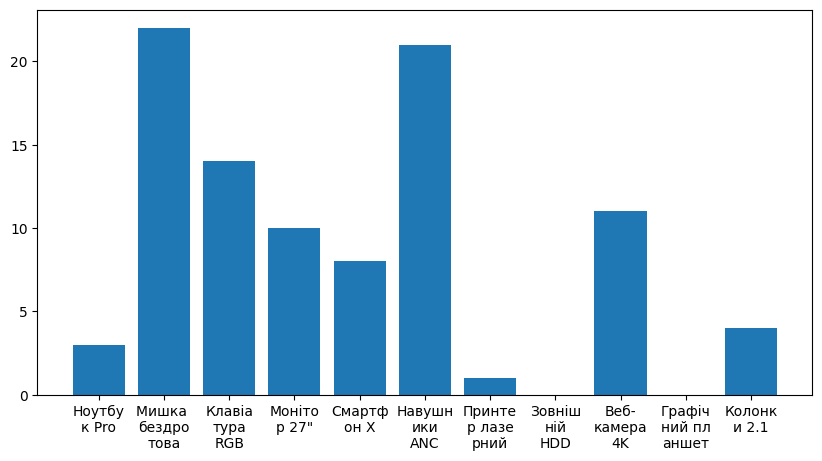

In [6]:
from textwrap import fill  # обмеження тексту за шириною
fig, ax = plt.subplots( figsize=(10,5) )
ax.bar([fill(name, width=6) for name in sales['Товар']], sales['Продано'])
plt.show()

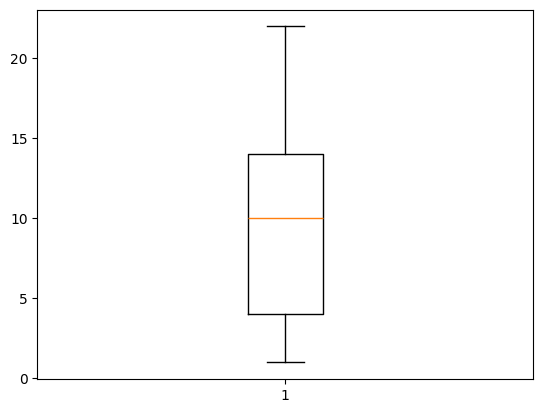

In [7]:
# коробчату діаграму
fig, ax = plt.subplots(  )                # Коробка (box) - центральна частина по квартилях
plt.boxplot( sales['Продано'].dropna() )  # IQR - міжквартильний проміжок
plt.show()                                # Вуса (whiskers) - на відстані 1.5 IQR від коробки (не далі мін,макс)

In [8]:
stat(sales)
stat(sales.dropna())

Продано усього: 94 шт
Середній продаж: 10.4 шт/назва
Медіана продажів: 10.0 шт
Найменша продаж: 1 шт
Найбільша продаж: 22 шт
Квартилі:
0.25     4.0
0.50    10.0
0.75    14.0
Name: Продано, dtype: float64
90-й перцентиль (90 % продажів містять не більше ніж): 21.2 шт
Продано усього: 76 шт
Середній продаж: 10.9 шт/назва
Медіана продажів: 10.0 шт
Найменша продаж: 1 шт
Найбільша продаж: 22 шт
Квартилі:
0.25     5.5
0.50    10.0
0.75    16.0
Name: Продано, dtype: float64
90-й перцентиль (90 % продажів містять не більше ніж): 21.4 шт


<hr/>

## Завдання 2
Потрібно змоделювати вибірку розмірів замовлень із додаванням викидів і провести базовий статистичний аналіз. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
- Створіть одновимірний масив додатних чисел і додайте кілька аномально великих значень.
- Перетворіть масив на таблицю з одним стовпчиком.
- Розрахуйте середнє, медіану, стандартне відхилення, IQR і MAD, коефіцієнти асиметрії та ексцесу.
- Побудуйте гістограму розподілу та коробчату діаграму.
- Визначте частку спостережень, що виходять за "вуса" коробчастої діаграми.
- Виведіть числові результати та графіки.

In [9]:
# Створіть одновимірний масив додатних чисел і додайте кілька аномально великих значень.
# Перетворіть масив на таблицю з одним стовпчиком.
data = pd.DataFrame({
    "Продано": [ *sales['Продано'].dropna(), 42 ]
})
data

,Продано
0,3.0
1,22.0
2,14.0
3,10.0
4,8.0
5,21.0
6,1.0
7,11.0
8,4.0
9,42.0


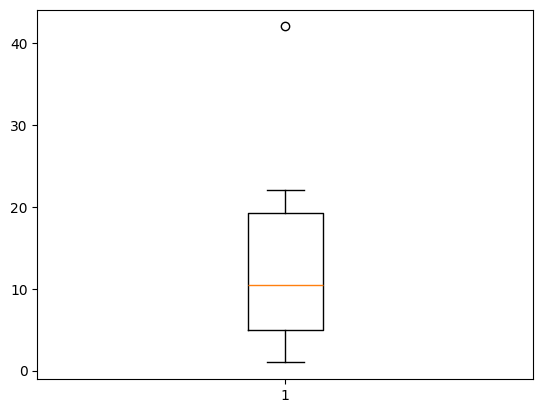

In [10]:
# коробчату діаграму
fig, ax = plt.subplots(  )    # Викиди (Outliers) - значення, що виходять за
plt.boxplot( data )           # межі "вусів" - відображаються як оркемі точки (кола)
plt.show()               

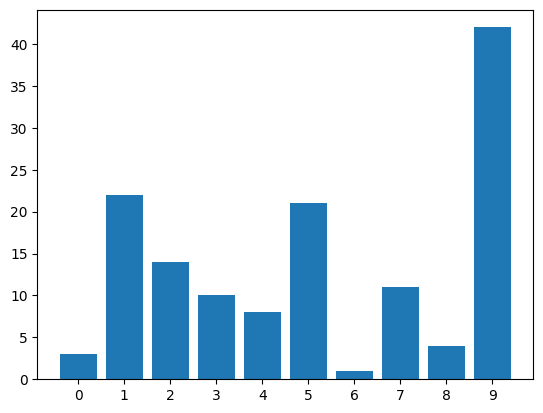

In [11]:
fig, ax = plt.subplots(  )
plt.bar( [str(i) for i in range(len(data))], data['Продано'] )
plt.show()

In [13]:
# Розрахуйте середнє, медіану, стандартне відхилення, IQR і MAD, коефіцієнти асиметрії та ексцесу.
Q1 = data['Продано'].quantile(0.25)
Q3 = data['Продано'].quantile(0.75)
IQR = Q3 - Q1
avg = data['Продано'].mean()
mad = (data['Продано'] - avg).abs().mean()  
print((
    "Середня кількість товарів на один продаж: %.1f шт\n" +
    "Медіана продажів: %.1f шт\n" +
    "Стандартне відхилення кількості продажів: %.1f шт\n" +
    "Середнє абсолютне відхилення кількості продажів: %.1f шт\n" +
    "Інтерквартильний розмах: %.1f\n" +
    "Коефіцієнт зміщення (або асиметрії) %.1f\n" +
    "Коефіцієнт ексцесу %.1f\n"
) % (
    avg,
    data['Продано'].median(),
    data['Продано'].std(),  # standart deviation
    mad, # MAD - mean (average) absolute deviation - Deprecated in Python (mean/median -> M)
    IQR,
    # коефіцієнт зміщення (або асиметрії) - skewness - ступінь відмінності розподілу величини від нормального "по горизонталі": 
    # =0 -- розподіл нормальний, >0 -- асиметрія праворуч
    data['Продано'].skew(),
    # коефіцієнт ексцесу - kurtosis - ступінь відмінності розподілу величини від нормального "по вертикалі": 
    # =0 -- розподіл нормальний, >0 -- гостра вершина, <0 -- плоска вершина
    data['Продано'].kurtosis(),
))

Середня кількість товарів на один продаж: 13.6 шт
Медіана продажів: 10.5 шт
Стандартне відхилення кількості продажів: 12.2 шт
Середнє абсолютне відхилення кількості продажів: 8.9 шт
Інтерквартильний розмах: 14.2
Коефіцієнт зміщення (або асиметрії) 1.5
Коефіцієнт ексцесу 2.5



In [17]:
# Визначте частку спостережень, що виходять за "вуса" коробчастої діаграми.
outliers = data[ (data['Продано'] > Q3 + 1.5 * IQR) | (data['Продано'] < 2) ]
len(outliers.index)

2